In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

In [21]:
sns.set_style("whitegrid")

In [22]:
df = pd.read_csv("NABIL.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
print("## Data Preview")
print(df.head())

## Data Preview
           Symbol    Open    High     Low   Close        Volume
Date                                                           
2011-03-20  NABIL  1200.0  1190.0  1160.0  1170.0  1,000,811.00
2011-03-24  NABIL  1162.0  1178.0  1150.0  1153.0    412,649.00
2011-03-25  NABIL  1153.0  1174.0  1145.0  1174.0    807,507.00
2011-03-27  NABIL  1174.0  1160.0  1120.0  1147.0  1,619,270.00
2011-03-28  NABIL  1147.0  1150.0  1110.0  1132.0    393,534.00


In [23]:
def create_windowed_data(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

In [24]:
def build_lstm_model(window_size):
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(window_size, 1)),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [25]:
data = df[['Close']]
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

In [26]:
# Define window size and split data
window_size = 60
train_size = int(len(data_scaled) * 0.8)
test_size = len(data_scaled) - train_size
train_data, test_data = data_scaled[:train_size], data_scaled[train_size-window_size:]

In [27]:
# Create windowed data
X_train, y_train = create_windowed_data(train_data, window_size)
X_test, y_test = create_windowed_data(test_data, window_size)


In [28]:
# Reshape data for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [29]:
# Train the model
model = build_lstm_model(window_size)
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200, batch_size=32, verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/200


c:\Users\BBhuwan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - loss: 0.0542 - val_loss: 2.2316e-04
Epoch 2/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0037 - val_loss: 3.6386e-04
Epoch 3/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0034 - val_loss: 2.8948e-04
Epoch 4/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0029 - val_loss: 1.3288e-04
Epoch 5/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0030 - val_loss: 1.9262e-04
Epoch 6/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0024 - val_loss: 1.7261e-04
Epoch 7/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0021 - val_loss: 1.0822e-04
Epoch 8/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0022 - val_loss: 1.0488e-04
Epoch 9/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0021 - val_loss: 1.3103e-04
Epoch 10/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0018 - val_loss: 1.8989e-04
Epoch 11/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0017 - val_loss: 1.3514e-04
Epoch 12/200
77/77 ━

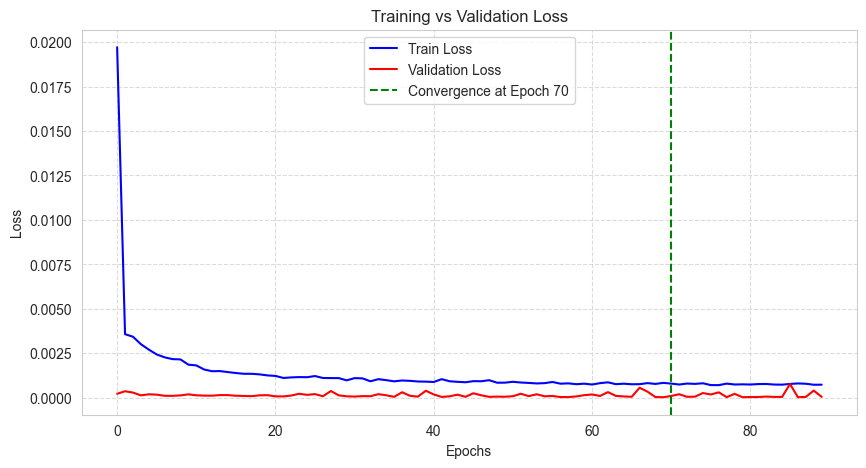

In [30]:
# Plot training and validation loss
min_val_loss_epoch = np.argmin(history.history['val_loss']) + 1
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.axvline(min_val_loss_epoch, linestyle='--', color='green', label=f'Convergence at Epoch {min_val_loss_epoch}')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


In [31]:
print(f"### Model converged at epoch {min_val_loss_epoch}")


### Model converged at epoch 70


In [32]:
# Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
y_test_unscaled = scaler.inverse_transform(y_test.reshape(-1, 1))


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step


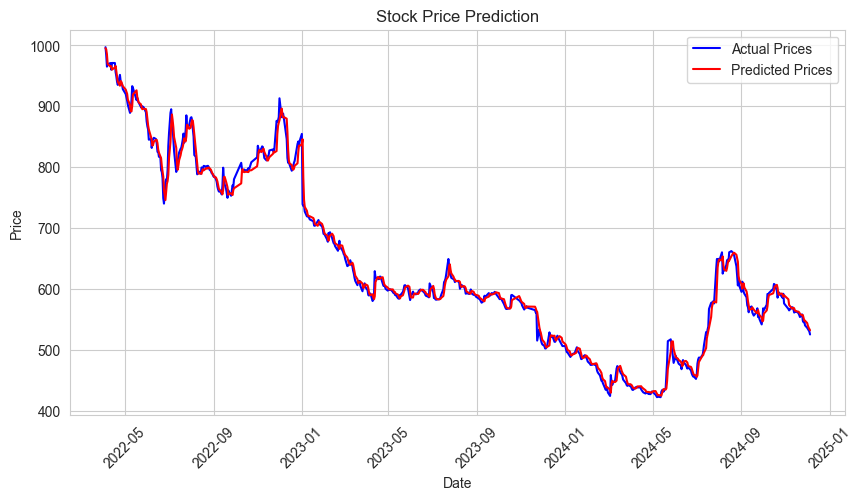

In [33]:
# Plot actual vs predicted prices
test_dates = df.index[-len(y_test):]
plt.figure(figsize=(10, 5))
plt.plot(test_dates, y_test_unscaled, label='Actual Prices', color='blue')
plt.plot(test_dates, predictions, label='Predicted Prices', color='red')
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price Prediction")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [34]:
# Performance Metrics
rmse = np.sqrt(mean_squared_error(y_test_unscaled, predictions))
mape = mean_absolute_percentage_error(y_test_unscaled, predictions) * 100
accuracy = 100 - mape

In [ ]:
print(f" RMSE: {rmse:.4f}")
print(f" MAPE: {mape:.2f}%")
print(f"Prediction Accuracy: {accuracy:.2f}%")


### RMSE: 12.2961
### MAPE: 1.24%
### Prediction Accuracy: 98.76%


In [36]:
# Residual Analysis
residuals = y_test_unscaled - predictions
residuals_flat = residuals.flatten()

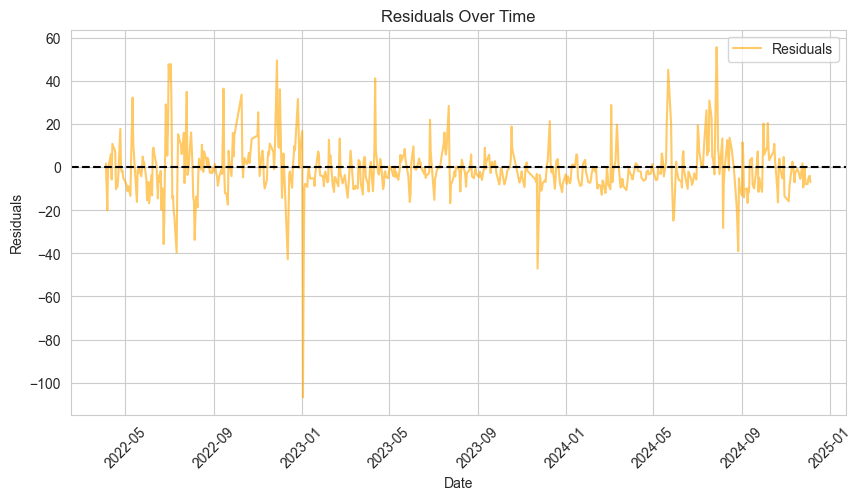

In [ ]:
# Residuals over time
plt.figure(figsize=(10, 5))
plt.plot(test_dates, residuals_flat, color='orange', alpha=0.6, label='Residuals')
plt.axhline(y=0, color='black', linestyle='--')
plt.title("Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.legend()
plt.xticks(rotation=45)
plt.show()

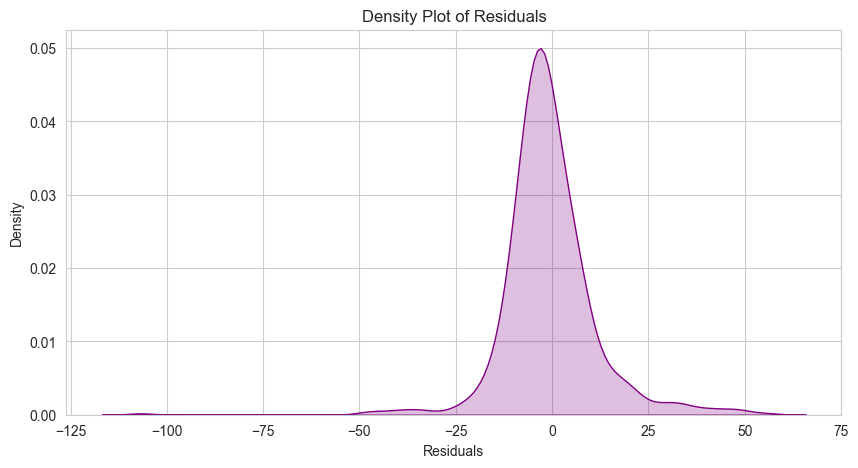

In [38]:
# Residual density plot
plt.figure(figsize=(10, 5))
sns.kdeplot(residuals_flat, fill=True, color='purple')
plt.title("Density Plot of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

In [39]:
# Future Forecast
future_steps = 30
future_input = data_scaled[-window_size:]
future_predictions = []

In [40]:
for _ in range(future_steps):
    future_input_reshaped = future_input.reshape((1, window_size, 1))
    next_prediction = model.predict(future_input_reshaped, verbose=0)[0, 0]
    future_predictions.append(next_prediction)
    future_input = np.append(future_input[1:], next_prediction).reshape(-1, 1)

In [41]:
future_predictions_unscaled = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))
future_dates = pd.date_range(start=df.index[-1], periods=future_steps + 1, freq='B')[1:]

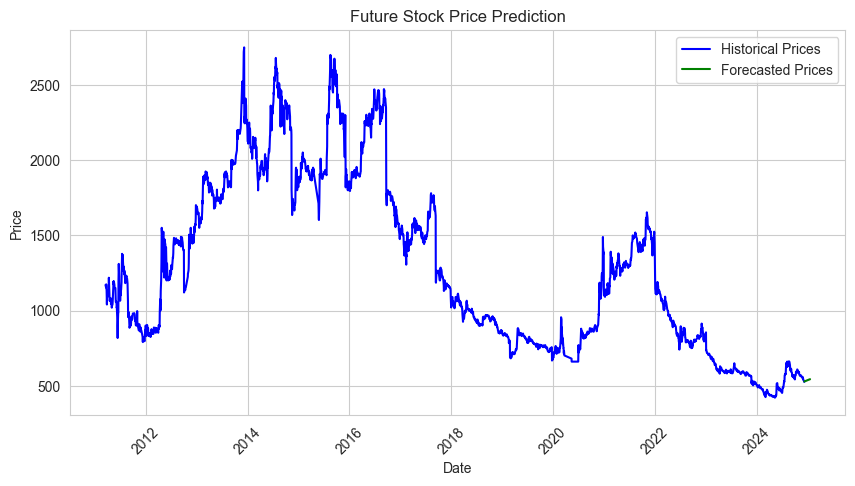

In [42]:
# Plot future predictions
plt.figure(figsize=(10, 5))
plt.plot(df.index, data['Close'], label='Historical Prices', color='blue')
plt.plot(future_dates, future_predictions_unscaled, label='Forecasted Prices', color='green')
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Future Stock Price Prediction")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [43]:
# Display future predictions in a table
future_df = pd.DataFrame({"Date": future_dates, "Predicted": future_predictions_unscaled.flatten()})
print(future_df)

         Date   Predicted
0  2024-12-06  528.421814
1  2024-12-09  528.352356
2  2024-12-10  528.856750
3  2024-12-11  529.464172
4  2024-12-12  530.080017
5  2024-12-13  530.677490
6  2024-12-16  531.250977
7  2024-12-17  531.803894
8  2024-12-18  532.342712
9  2024-12-19  532.873901
10 2024-12-20  533.402832
11 2024-12-23  533.932617
12 2024-12-24  534.464783
13 2024-12-25  534.999390
14 2024-12-26  535.535706
15 2024-12-27  536.072388
16 2024-12-30  536.607727
17 2024-12-31  537.140259
18 2025-01-01  537.668945
19 2025-01-02  538.192749
20 2025-01-03  538.710999
21 2025-01-06  539.223572
22 2025-01-07  539.730103
23 2025-01-08  540.230835
24 2025-01-09  540.725891
25 2025-01-10  541.215576
26 2025-01-13  541.700195
27 2025-01-14  542.180115
28 2025-01-15  542.655579
29 2025-01-16  543.126892
